In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/preprocessed/imputed_data.csv')

feature_cols = [col for col in df.columns if col not in
                ["result_match", "stage", "season", "date", "home_team", "away_team"]]

y = df[['result_match']]
X = df[feature_cols].copy()


def freedman_diaconis_bins(series):
    """
    Calculate the optimal number of bins using the Freedman-Diaconis rule.
    """
    data = series.dropna()

    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25

    bin_width = 2 * iqr / np.cbrt(len(data))

    if bin_width == 0:
        return 10

    data_range = data.max() - data.min()
    n_bins = int(np.ceil(data_range / bin_width))
    return n_bins

Optimal bins for rolling_avg_goals_home: 47
Optimal bins for rolling_avg_shoton_home: 47


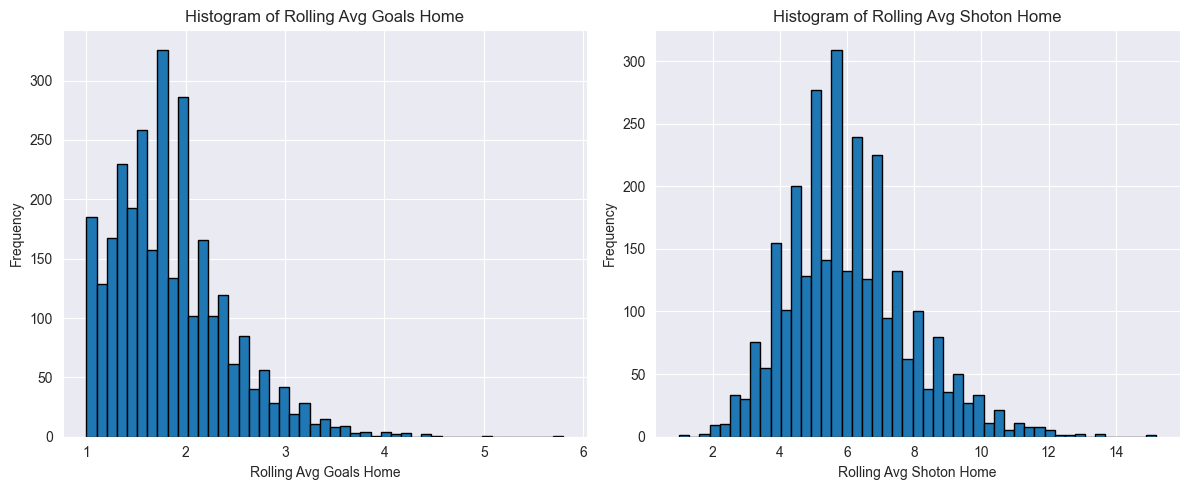

In [2]:
n_bins_goals = freedman_diaconis_bins(X['rolling_avg_goals_home'])
n_bins_shoton = freedman_diaconis_bins(X['rolling_avg_shoton_home'])

print(f"Optimal bins for rolling_avg_goals_home: {n_bins_goals}")
print(f"Optimal bins for rolling_avg_shoton_home: {n_bins_shoton}")

X['goals_bin'] = pd.cut(X['rolling_avg_goals_home'], bins=n_bins_goals).cat.codes
X['shoton_bin'] = pd.cut(X['rolling_avg_shoton_home'], bins=n_bins_shoton).cat.codes

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['rolling_avg_goals_home'].dropna(), bins=n_bins_goals, edgecolor='black')
plt.title('Histogram of Rolling Avg Goals Home')
plt.xlabel('Rolling Avg Goals Home')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['rolling_avg_shoton_home'].dropna(), bins=n_bins_shoton, edgecolor='black')
plt.title('Histogram of Rolling Avg Shoton Home')
plt.xlabel('Rolling Avg Shoton Home')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [3]:
# Optional: Display the first few rows to verify
X[['rolling_avg_goals_home', 'goals_bin', 'rolling_avg_shoton_home', 'shoton_bin']]

,rolling_avg_goals_home,goals_bin,rolling_avg_shoton_home,shoton_bin
0,1.000000,0,12.0,36
1,2.000000,9,5.0,13
2,1.000000,0,7.0,19
3,3.000000,19,5.0,13
4,1.000000,0,5.0,13
...,...,...,...,...
2973,1.200000,1,5.2,13
2974,2.466667,14,5.0,13
2975,1.900000,8,8.4,24
2976,1.750000,7,3.6,8


In [4]:
X.columns

Index(['match_api_id', 'points_home', 'points_away', 'home_last_team_goal',
       'home_last_team_shoton', 'home_last_team_possession',
       'away_last_team_goal', 'away_last_team_shoton',
       'away_last_team_possession', 'team_strength_home', 'team_strength_away',
       'strength_difference', 'team_aggression_home', 'team_aggression_away',
       'aggression_difference', 'team_acceleration_home',
       'team_acceleration_away', 'acceleration_difference',
       'goal_conversion_rate_home', 'goal_conversion_rate_away',
       'rolling_avg_goals_home', 'rolling_stability_goal_home',
       'rolling_avg_goals_conversion_rate_home',
       'rolling_stability_goals_conversion_rate_home',
       'rolling_avg_shoton_home', 'rolling_stability_shoton_home',
       'rolling_avg_goals_away', 'rolling_stability_goal_away',
       'rolling_avg_goals_conversion_rate_away',
       'rolling_stability_goals_conversion_rate_away',
       'rolling_avg_shoton_away', 'rolling_stability_shoton_away

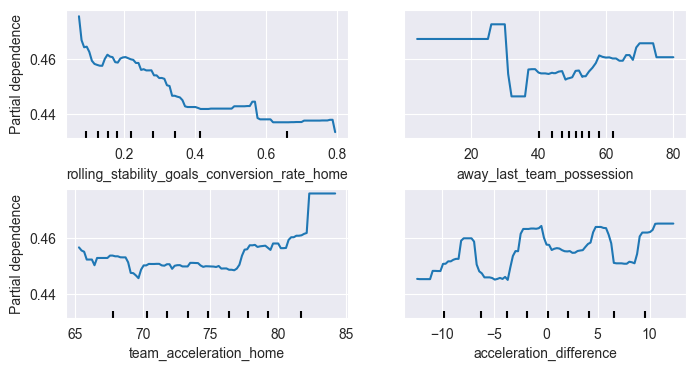

In [5]:
from src.eda.PartialDependencyAnalyzer import PartialDependenceAnalyzer

analyzer_pdp = PartialDependenceAnalyzer(
    features=[
        'rolling_stability_goals_conversion_rate_home', 'away_last_team_possession', 'team_acceleration_home', 'acceleration_difference'
    ],
    model_params={
        'max_depth': 5,
        'n_estimators': 400
    },
    threshold=0.49,
    plot_type='average'

)

analyzer_pdp.fit_and_visualize(X, y, )

In [6]:
potential_features_for_binning = ['home_last_team_possession', # [<40], [40–70], [>70]
                                  'rolling_avg_goals_home',  # [<1,5], [1,5-2,5], [2,5<]
                                  'rolling_avg_shoton_home',  # [<5], [5-6,4], [6,4<]
                                  'away_last_team_possession',  # [<40], [40–50], [50–60], [>60]
                                  'team_acceleration_home',  # [<70], [70–75], [75–82], [>82]
                                  'goal_conversion_rate_home',  # [<0,2], [0,2-0,6], [0,6<]
                                  'rolling_stability_goals_conversion_rate_home',  # [>0,2], [0,2-0,4], [0,4<]
                                  'rolling_avg_goals_away',  # [<1,5], [1,5-2], [2-2,5], [2,5<]
                                  'rolling_stability_goal_away',  # [<0,5], [0,5-1,1], [>1,1] / [0-0,5], [0,5-1], [1<]
                                  'rolling_avg_goals_conversion_rate_away',  # [<0,35], [0,35-0,45], [0,45<]
                                  'rolling_stability_goals_conversion_rate_away', # [<0,1], [0,1-0,37], [0,37<0,6], [0,6<]
                                  'rolling_avg_shoton_away',  # [<5,5], [5,5-6,5], [6,5<]
                                  'rolling_stability_shoton_away',  # [<1,5], [1,5-4,2], [4,2<]
                                  'rolling_avg_goals_conversion_rate_diff', # [<-0,2], [-0,2-0,2], [0,2<] / [<-0.2], [-0.2 do 0], [0 do 0.2], [>0.2]
                                  'rolling_stability_goals_conversion_rate_diff', # [<-0,25], [-0,25-0], [0-0,25<], [0,25<]
                                  'rolling_stability_shoton_diff',  # [<-1], [-1 - 0], [-0<1], [1<]
                                  'points_diff',  # [<-15 - -5], [-5 - 10], [10 < 20], [20<]
                                  'points_ratio',  # [<1,25], [1,25 - 1,75], [1,75 < ]
                                  ]

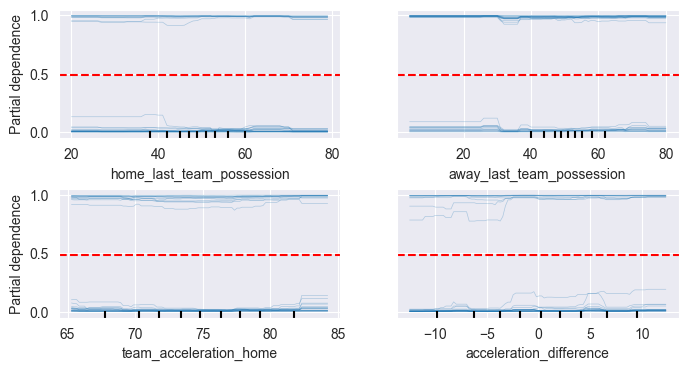

In [7]:
analyzer_ice = PartialDependenceAnalyzer(
    features=[
        'home_last_team_possession', 'away_last_team_possession', 'team_acceleration_home', 'acceleration_difference'
    ],
    model_params={
        'max_depth': 5,
        'n_estimators': 400
    },
    threshold=0.49,
    plot_type='individual'
)

analyzer_ice.fit_and_visualize(X, y, )